# EDA

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('data/train.csv')

In [3]:
df.shape

(1460, 81)

In [4]:
df.head

<bound method NDFrame.head of         Id  MSSubClass MSZoning  LotFrontage  LotArea Street Alley LotShape  \
0        1          60       RL         65.0     8450   Pave   NaN      Reg   
1        2          20       RL         80.0     9600   Pave   NaN      Reg   
2        3          60       RL         68.0    11250   Pave   NaN      IR1   
3        4          70       RL         60.0     9550   Pave   NaN      IR1   
4        5          60       RL         84.0    14260   Pave   NaN      IR1   
...    ...         ...      ...          ...      ...    ...   ...      ...   
1455  1456          60       RL         62.0     7917   Pave   NaN      Reg   
1456  1457          20       RL         85.0    13175   Pave   NaN      Reg   
1457  1458          70       RL         66.0     9042   Pave   NaN      Reg   
1458  1459          20       RL         68.0     9717   Pave   NaN      Reg   
1459  1460          20       RL         75.0     9937   Pave   NaN      Reg   

     LandContour Util

In [5]:
df.isna().mean().sort_values(ascending=False).head(20)


PoolQC          0.995205
MiscFeature     0.963014
Alley           0.937671
Fence           0.807534
MasVnrType      0.597260
FireplaceQu     0.472603
LotFrontage     0.177397
GarageYrBlt     0.055479
GarageCond      0.055479
GarageType      0.055479
GarageFinish    0.055479
GarageQual      0.055479
BsmtFinType2    0.026027
BsmtExposure    0.026027
BsmtQual        0.025342
BsmtCond        0.025342
BsmtFinType1    0.025342
MasVnrArea      0.005479
Electrical      0.000685
Id              0.000000
dtype: float64

In [6]:
df['SalePrice'].describe()


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

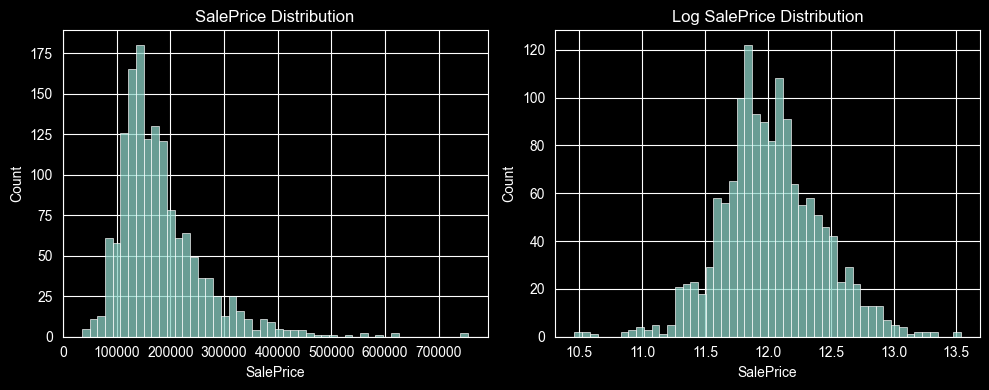

In [7]:
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.histplot(df['SalePrice'], bins=50)
plt.title('SalePrice Distribution')

plt.subplot(1, 2, 2)
sns.histplot(np.log1p(df['SalePrice']), bins=50)
plt.title('Log SalePrice Distribution')

plt.tight_layout()
plt.show()

# Cleaning

In [8]:
from sklearn.model_selection import train_test_split

train, test = train_test_split(df, test_size=0.2, random_state=42)
print(train.shape, test.shape)

(1168, 81) (292, 81)


### cleaning approach 1: drop >40% missing, fill numerical with median, fill categorical with mode

In [9]:
y_train = np.log1p(train['SalePrice'])
y_test = np.log1p(test['SalePrice'])

X_train = train.drop(columns=['SalePrice'])
X_test = test.drop(columns=['SalePrice'])

X_train = train.drop(columns=['SalePrice', 'Id'])
X_test = test.drop(columns=['SalePrice', 'Id'])

print(X_train.shape, X_test.shape)

(1168, 79) (292, 79)


In [10]:
missing = X_train.isna().mean().sort_values(ascending=False)
missing[missing > 0]

PoolQC          0.994863
MiscFeature     0.960616
Alley           0.936644
Fence           0.800514
MasVnrType      0.584760
FireplaceQu     0.468322
LotFrontage     0.185788
GarageCond      0.054795
GarageType      0.054795
GarageYrBlt     0.054795
GarageQual      0.054795
GarageFinish    0.054795
BsmtFinType2    0.023973
BsmtFinType1    0.023973
BsmtExposure    0.023973
BsmtCond        0.023973
BsmtQual        0.023973
MasVnrArea      0.005137
Electrical      0.000856
dtype: float64

In [11]:
# dropping columns with more than 40% missing values
cols_to_drop = missing[missing > 0.4].index.tolist()
print(cols_to_drop)

X_train = X_train.drop(columns=cols_to_drop)
X_test = X_test.drop(columns=cols_to_drop)
print(X_train.shape, X_test.shape)

['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'MasVnrType', 'FireplaceQu']
(1168, 73) (292, 73)


In [12]:
X_train.isna().mean().sort_values(ascending=False).head(20)

LotFrontage     0.185788
GarageType      0.054795
GarageCond      0.054795
GarageYrBlt     0.054795
GarageFinish    0.054795
GarageQual      0.054795
BsmtFinType2    0.023973
BsmtFinType1    0.023973
BsmtExposure    0.023973
BsmtCond        0.023973
BsmtQual        0.023973
MasVnrArea      0.005137
Electrical      0.000856
PavedDrive      0.000000
PoolArea        0.000000
LowQualFinSF    0.000000
GrLivArea       0.000000
BsmtFullBath    0.000000
BsmtHalfBath    0.000000
FullBath        0.000000
dtype: float64

In [13]:
cat_cols = [col for col in X_train.columns if X_train[col].dtype == 'object']
num_cols = [col for col in X_train.columns if X_train[col].dtype != 'object']
print(f"Categorical : {len(cat_cols)}")
print(f"Numerical: {len(num_cols)}")

Categorical : 37
Numerical: 36


In [14]:
# numerical median
for col in num_cols:
    X_train[col].fillna(X_train[col].median(), inplace=True)
    X_test[col].fillna(X_train[col].median(), inplace=True)

# categorical mode
for col in cat_cols:
    X_train[col].fillna(X_train[col].mode()[0], inplace=True)
    X_test[col].fillna(X_train[col].mode()[0], inplace=True)

/var/folders/3w/hy4_kht12zq4p93lg6m854gr0000gn/T/ipykernel_26548/1601387223.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  X_train[col].fillna(X_train[col].median(), inplace=True)
/var/folders/3w/hy4_kht12zq4p93lg6m854gr0000gn/T/ipykernel_26548/1601387223.py:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting val

In [15]:
print(X_train.isna().sum().sum())
print(X_test.isna().sum().sum())

0
0


### cleaning approach 2. remove outliers, fill numerical with mean instead of median

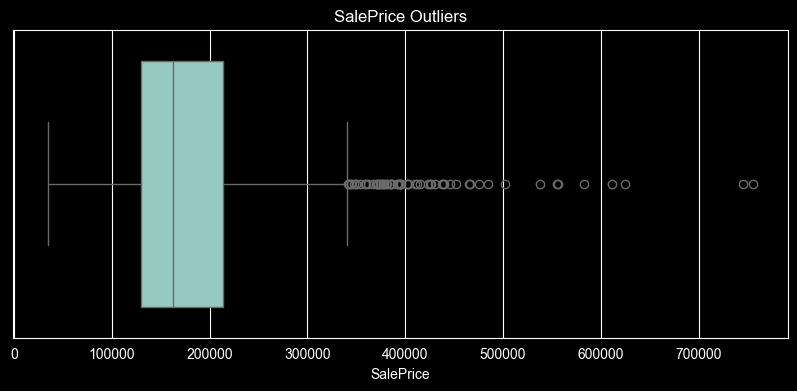

In [16]:
# outliers
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['SalePrice'])
plt.title('SalePrice Outliers')
plt.show()

In [17]:
train2 = train.copy()
test2 = test.copy()

In [18]:
# remove outliers
print(f"before: {train2.shape[0]}")
train2 = train2[train2['SalePrice'] < 500000]
print(f"after: {train2.shape[0]}")

before: 1168
after: 1162


In [19]:
# cleaning approach 2. i am using mean and outliers are removed
y_train2 = np.log1p(train2['SalePrice'])
y_test2 = np.log1p(test2['SalePrice'])

X_train2 = train2.drop(columns=['SalePrice'])
X_test2 = test2.drop(columns=['SalePrice'])

X_train2 = train2.drop(columns=['SalePrice', 'Id'])
X_test2 = test2.drop(columns=['SalePrice', 'Id'])

# drop high missing columns
X_train2 = X_train2.drop(columns=cols_to_drop)
X_test2 = X_test2.drop(columns=cols_to_drop)

# here lets fill numericals with mean (instead of median)
for col in num_cols:
    mean_val = X_train2[col].mean()
    X_train2[col] = X_train2[col].fillna(mean_val)
    X_test2[col] = X_test2[col].fillna(mean_val)

# fill categorical with mode
for col in cat_cols:
    mode_val = X_train2[col].mode()[0]
    X_train2[col] = X_train2[col].fillna(mode_val)
    X_test2[col] = X_test2[col].fillna(mode_val)

# Feature Engineering

### engineering approach 1: one hot encoding on cleaning Approach 1 data

In [20]:
print(cat_cols)
print(len(cat_cols))


['MSZoning', 'Street', 'LotShape', 'LandContour', 'Utilities', 'LotConfig', 'LandSlope', 'Neighborhood', 'Condition1', 'Condition2', 'BldgType', 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st', 'Exterior2nd', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC', 'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond', 'PavedDrive', 'SaleType', 'SaleCondition']
37


In [21]:
X_train_encoded = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test_encoded = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)

print(X_train_encoded.shape)
print(X_test_encoded.shape)

(1168, 227)
(292, 193)


In [22]:
X_train_encoded, X_test_encoded = X_train_encoded.align(X_test_encoded, join='left', axis=1, fill_value=0)

print(X_train_encoded.shape)
print(X_test_encoded.shape)

(1168, 227)
(292, 227)


In [23]:
X_train_encoded.head()


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial
254,20,70.0,8400,5,6,1957,1957,0.0,922,0,...,False,False,False,False,True,False,False,False,True,False
1066,60,59.0,7837,6,7,1993,1994,0.0,0,0,...,False,False,False,False,True,False,False,False,True,False
638,30,67.0,8777,5,7,1910,1950,0.0,0,0,...,False,False,False,False,True,False,False,False,True,False
799,50,60.0,7200,5,7,1937,1950,252.0,569,0,...,False,False,False,False,True,False,False,False,True,False
380,50,50.0,5000,5,6,1924,1950,0.0,218,0,...,False,False,False,False,True,False,False,False,True,False


In [24]:
X_train_encoded.shape
X_train_encoded.dtypes.value_counts()

bool       191
int64       33
float64      3
Name: count, dtype: int64

In [25]:
# some columns are boolean, so i am converting them to 0/1
X_train_encoded = X_train_encoded.astype(int)
X_test_encoded = X_test_encoded.astype(int)

X_train_encoded.dtypes.value_counts()

int64    227
Name: count, dtype: int64

### engineering approach 2: one hot encoding on cleaning approach 2 data

In [26]:
X_train2_encoded = pd.get_dummies(X_train2, columns=cat_cols, drop_first=True)
X_test2_encoded = pd.get_dummies(X_test2, columns=cat_cols, drop_first=True)

In [27]:
X_train2_encoded, X_test2_encoded = X_train2_encoded.align(X_test2_encoded, join='left', axis=1, fill_value=0)

In [28]:
X_train2_encoded = X_train2_encoded.astype(int)
X_test2_encoded = X_test2_encoded.astype(int)

print(X_train2_encoded.shape)
print(X_test2_encoded.shape)

(1162, 227)
(292, 227)


# Feature Selection

### no selection

In [29]:
# now i will check correlation with target
correlation = X_train_encoded.corrwith(y_train).abs().sort_values(ascending=False)
correlation.head(20)

OverallQual         0.807946
GrLivArea           0.689012
GarageCars          0.684451
GarageArea          0.654520
TotalBsmtSF         0.597214
FullBath            0.583747
ExterQual_TA        0.583589
1stFlrSF            0.580948
YearBuilt           0.576725
GarageFinish_Unf    0.573800
YearRemodAdd        0.562152
BsmtQual_TA         0.538992
KitchenQual_TA      0.527992
TotRmsAbvGrd        0.520082
Foundation_PConc    0.518922
ExterQual_Gd        0.498680
Fireplaces          0.481761
GarageYrBlt         0.481453
BsmtFinType1_GLQ    0.430941
MasVnrArea          0.419978
dtype: float64

### correlation filter

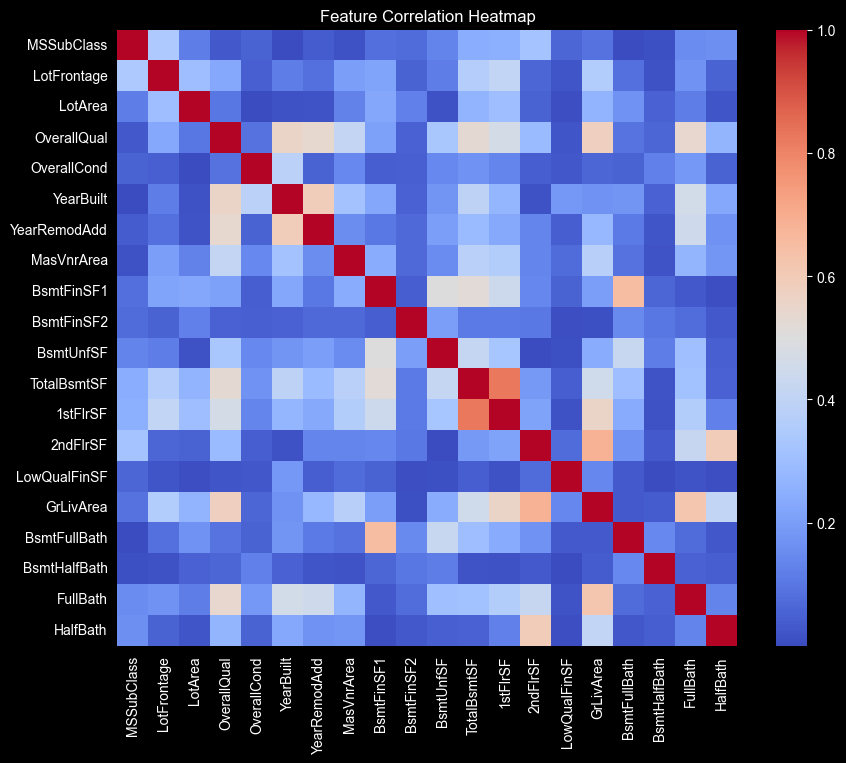

In [30]:
# here i will check correlation between features
corr_matrix = X_train_encoded.corr().abs()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix.iloc[:20, :20], cmap='coolwarm')
plt.title('Feature Correlation Heatmap')
plt.show()

In [31]:
# now i will remove the features that are highly correlated
threshold = 0.8

cols_to_drop_corr = set()
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if corr_matrix.iloc[i, j] > threshold:
            cols_to_drop_corr.add(corr_matrix.columns[j])

print(f"Columns to drop: {len(cols_to_drop_corr)}")
print(cols_to_drop_corr)

Columns to drop: 21
{'1stFlrSF', 'Exterior2nd_MetalSd', 'KitchenQual_TA', 'RoofStyle_Hip', 'Exterior2nd_CBlock', 'MSZoning_RM', 'BsmtQual_TA', 'TotRmsAbvGrd', 'BsmtFinType2_Unf', 'GarageQual_TA', 'Exterior2nd_Wd Sdng', 'Exterior2nd_HdBoard', 'HouseStyle_2Story', 'Exterior2nd_CmentBd', 'SaleCondition_Partial', 'Exterior2nd_VinylSd', 'GarageType_Detchd', 'GarageArea', 'Neighborhood_Somerst', 'ExterCond_TA', 'ExterQual_TA'}


In [32]:
X_train_filtered = X_train_encoded.drop(columns=cols_to_drop_corr)
X_test_filtered = X_test_encoded.drop(columns=cols_to_drop_corr)

print(X_train_filtered.shape)
print(X_test_filtered.shape)

(1168, 206)
(292, 206)


### RFE

In [33]:
# now  i will do second feature selection approach which is RFE
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

model_rfe = LinearRegression()
rfe = RFE(model_rfe, n_features_to_select=100)
rfe.fit(X_train_filtered, y_train)
selected_features = X_train_filtered.columns[rfe.support_]
print(f"Selected features: {len(selected_features)}")

X_train_rfe = X_train_filtered[selected_features]
X_test_rfe = X_test_filtered[selected_features]

print(X_train_rfe.shape)
print(X_test_rfe.shape)

Selected features: 100
(1168, 100)
(292, 100)


### RFE on cleaning approach 2 data

In [34]:
rfe2 = RFE(LinearRegression(), n_features_to_select=100)
rfe2.fit(X_train2_encoded, y_train2)

selected_features2 = X_train2_encoded.columns[rfe2.support_]

X_train2_rfe = X_train2_encoded[selected_features2]
X_test2_rfe = X_test2_encoded[selected_features2]

print(X_train2_rfe.shape)
print(X_test2_rfe.shape)

(1162, 100)
(292, 100)


### Feature Importance based selection (for tree-based models)

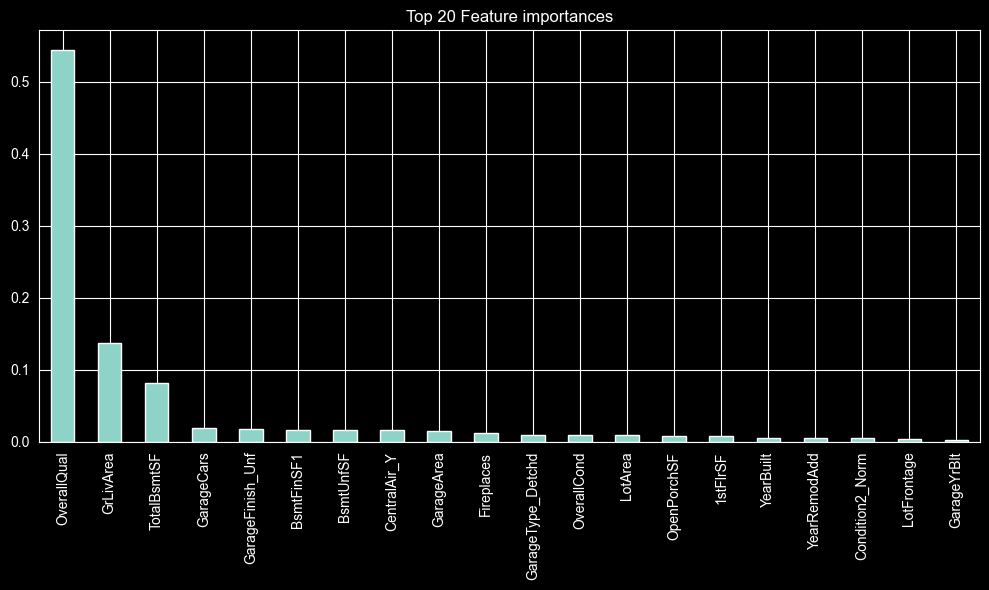

(1168, 100)
(292, 100)


In [43]:
from sklearn.tree import DecisionTreeRegressor

dt_selector = DecisionTreeRegressor(max_depth=10, random_state=42)
dt_selector.fit(X_train_encoded, y_train)

feature_importances = pd.Series(dt_selector.feature_importances_, index=X_train_encoded.columns)
feature_importances = feature_importances.sort_values(ascending=False)

# plot top 20
plt.figure(figsize=(10, 6))
feature_importances.head(20).plot(kind='bar')
plt.title('Top 20 Feature importances')
plt.tight_layout()
plt.show()

selected_features_dt = feature_importances.head(100).index

X_train_dt = X_train_encoded[selected_features_dt]
X_test_dt = X_test_encoded[selected_features_dt]

print(X_train_dt.shape)
print(X_test_dt.shape)

# Training

In [35]:
import mlflow
import mlflow.sklearn
import dagshub
from sklearn.metrics import mean_squared_error, r2_score

dagshub.init(repo_owner='gdzag22', repo_name='ml_assignment_1', mlflow=True)

Accessing as gdzag22

Initialized MLflow to track repo "gdzag22/ml_assignment_1"

Repository gdzag22/ml_assignment_1 initialized!

In [36]:
mlflow.set_experiment("house-prices-experiments")

<Experiment: artifact_location='mlflow-artifacts:/e3731ec99944460ea8c54ce7d7091d09', creation_time=1775874801604, experiment_id='0', last_update_time=1775874801604, lifecycle_stage='active', name='house-prices-experiments', tags={}, workspace='default'>

### Linear Regression. No Feature Selection

In [89]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

# here its training on all columns (no feature selection, only one hot encoding)
with mlflow.start_run(run_name="linear_regression_all_features"):
    model = LinearRegression()
    model.fit(X_train_encoded, y_train)

    train_preds = model.predict(X_train_encoded)
    test_preds = model.predict(X_test_encoded)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R2: {train_r2:.4f}")
    print(f"Test R2: {test_r2:.4f}")

    mlflow.log_param("model", "LinearRegression")
    mlflow.log_param("feature_selection", "none")
    mlflow.log_param("n_features", X_train_encoded.shape[1])
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.sklearn.log_model(model, "model")

Train RMSE: 0.0927
Test RMSE: 2.7342
Train R2: 0.9436
Test R2: -39.0623


2026/04/11 20:39:59 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 20:40:04 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run linear_regression_all_features at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0/runs/8139132cd25a440c8b4f45120d7856f0
🧪 View experiment at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0


### Linear Regression. Correlation Filter

In [90]:
with mlflow.start_run(run_name="linear_regression_corr_filter"):
    model = LinearRegression()
    model.fit(X_train_filtered, y_train)

    train_preds = model.predict(X_train_filtered)
    test_preds = model.predict(X_test_filtered)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R2: {train_r2:.4f}")
    print(f"Test R2: {test_r2:.4f}")

    mlflow.log_param("model", "LinearRegression")
    mlflow.log_param("feature_selection", "correlation_filter")
    mlflow.log_param("n_features", X_train_filtered.shape[1])
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.sklearn.log_model(model, "model")

Train RMSE: 0.0960
Test RMSE: 2.6499
Train R2: 0.9396
Test R2: -36.6277


2026/04/11 20:40:19 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 20:40:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run linear_regression_corr_filter at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0/runs/b54c107a1a2b45b6ab3d87ddd4312856
🧪 View experiment at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0


### Linear Regression. RFE

In [91]:
with mlflow.start_run(run_name="linear_regression_rfe"):
    model = LinearRegression()
    model.fit(X_train_rfe, y_train)

    train_preds = model.predict(X_train_rfe)
    test_preds = model.predict(X_test_rfe)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R2: {train_r2:.4f}")
    print(f"Test R2: {test_r2:.4f}")

    mlflow.log_param("model", "LinearRegression")
    mlflow.log_param("feature_selection", "rfe")
    mlflow.log_param("n_features", X_train_rfe.shape[1])
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.sklearn.log_model(model, "model")

Train RMSE: 0.1264
Test RMSE: 1.0811
Train R2: 0.8952
Test R2: -5.2634


2026/04/11 20:41:25 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 20:41:29 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run linear_regression_rfe at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0/runs/ab46fcefa1464ea396f6adcfb0d8f6fb
🧪 View experiment at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0


### Linear Regression. RFE and cleaning approach 2

In [92]:
with mlflow.start_run(run_name="linear_regression_cleaning2_rfe"):
    model = LinearRegression()
    model.fit(X_train2_rfe, y_train2)

    train_preds = model.predict(X_train2_rfe)
    test_preds = model.predict(X_test2_rfe)

    train_rmse = np.sqrt(mean_squared_error(y_train2, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test2, test_preds))
    train_r2 = r2_score(y_train2, train_preds)
    test_r2 = r2_score(y_test2, test_preds)

    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R2: {train_r2:.4f}")
    print(f"Test R2: {test_r2:.4f}")

    mlflow.log_param("model", "LinearRegression")
    mlflow.log_param("feature_selection", "rfe")
    mlflow.log_param("cleaning", "approach2_outliers_removed")
    mlflow.log_param("n_features", X_train2_rfe.shape[1])
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.sklearn.log_model(model, "model")

Train RMSE: 0.1269
Test RMSE: 1.0441
Train R2: 0.8890
Test R2: -4.8423


2026/04/11 20:41:47 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 20:41:55 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run linear_regression_cleaning2_rfe at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0/runs/47f8ba1660484300be1b4dd72ca768f8
🧪 View experiment at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0


### Ridge Regression: alpha=100

In [95]:
from sklearn.linear_model import Ridge

with mlflow.start_run(run_name="ridge_regression_rfe"):
    model = Ridge(alpha=100)
    model.fit(X_train_rfe, y_train)

    train_preds = model.predict(X_train_rfe)
    test_preds = model.predict(X_test_rfe)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R2: {train_r2:.4f}")
    print(f"Test R2: {test_r2:.4f}")

    mlflow.log_param("model", "Ridge")
    mlflow.log_param("alpha", 100)
    mlflow.log_param("feature_selection", "rfe")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.sklearn.log_model(model, "model")

Train RMSE: 0.1582
Test RMSE: 0.1795
Train R2: 0.8358
Test R2: 0.8273


2026/04/11 20:51:23 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 20:51:27 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run ridge_regression_rfe at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0/runs/8e5806d24d4f43ac961b928236cb56ba
🧪 View experiment at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0


### Ridge Regression - alpha=0.01 (underregularized)

In [96]:
with mlflow.start_run(run_name="ridge_regression_alpha_001"):
    model = Ridge(alpha=0.01)
    model.fit(X_train_rfe, y_train)

    train_preds = model.predict(X_train_rfe)
    test_preds = model.predict(X_test_rfe)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R2: {train_r2:.4f}")
    print(f"Test R2: {test_r2:.4f}")

    mlflow.log_param("model", "Ridge")
    mlflow.log_param("alpha", 0.01)
    mlflow.log_param("feature_selection", "rfe")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.sklearn.log_model(model, "model")

Train RMSE: 0.1264
Test RMSE: 1.0052
Train R2: 0.8952
Test R2: -4.4147


2026/04/11 20:56:21 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 20:56:24 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run ridge_regression_alpha_001 at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0/runs/05d9ee47ca2c45c6b27cd0666e42e193
🧪 View experiment at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0


### Ridge Regression. alpha=10000 (overregularized)

In [97]:
with mlflow.start_run(run_name="ridge_regression_alpha_10000"):
    model = Ridge(alpha=10000)
    model.fit(X_train_rfe, y_train)

    train_preds = model.predict(X_train_rfe)
    test_preds = model.predict(X_test_rfe)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R2: {train_r2:.4f}")
    print(f"Test R2: {test_r2:.4f}")

    mlflow.log_param("model", "Ridge")
    mlflow.log_param("alpha", 10000)
    mlflow.log_param("feature_selection", "rfe")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.sklearn.log_model(model, "model")

Train RMSE: 0.3263
Test RMSE: 0.3629
Train R2: 0.3018
Test R2: 0.2943


2026/04/11 20:57:43 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 20:57:46 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run ridge_regression_alpha_10000 at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0/runs/764d02fb857343938d697ca8891a31c1
🧪 View experiment at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0


### Lasso Regression. alpha=0.001

In [136]:
from sklearn.linear_model import Lasso

with mlflow.start_run(run_name="lasso_regression_rfe"):
    model = Lasso(alpha=0.001)
    model.fit(X_train_rfe, y_train)

    train_preds = model.predict(X_train_rfe)
    test_preds = model.predict(X_test_rfe)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R2: {train_r2:.4f}")
    print(f"Test R2: {test_r2:.4f}")

    mlflow.log_param("model", "Lasso")
    mlflow.log_param("alpha", 0.001)
    mlflow.log_param("feature_selection", "rfe")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.sklearn.log_model(model, "model")

Train RMSE: 0.1453
Test RMSE: 0.1678
Train R2: 0.8614
Test R2: 0.8491


2026/04/11 21:27:15 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 21:27:18 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lasso_regression_rfe at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0/runs/5c218ca03318440eb14fa674bfdab821
🧪 View experiment at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0


### Lasso Regression. alpha=1 (underfit)

In [99]:
from sklearn.linear_model import Lasso

with mlflow.start_run(run_name="lasso_regression_alpha_1"):
    model = Lasso(alpha=1)
    model.fit(X_train_rfe, y_train)

    train_preds = model.predict(X_train_rfe)
    test_preds = model.predict(X_test_rfe)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R2: {train_r2:.4f}")
    print(f"Test R2: {test_r2:.4f}")

    mlflow.log_param("model", "Lasso")
    mlflow.log_param("alpha", 1)
    mlflow.log_param("feature_selection", "rfe")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.sklearn.log_model(model, "model")

Train RMSE: 0.3904
Test RMSE: 0.4332
Train R2: 0.0000
Test R2: -0.0058


2026/04/11 21:02:57 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/11 21:03:01 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lasso_regression_alpha_1 at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0/runs/2b0aed0b4ce343b4a5f320860dc2eae7
🧪 View experiment at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0


### Ridge Regression. Scaled. alpha=100

In [38]:
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge

with mlflow.start_run(run_name="ridge_scaled_alpha100"):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Ridge(alpha=100))
    ])

    pipeline.fit(X_train_rfe, y_train)

    train_preds = pipeline.predict(X_train_rfe)
    test_preds = pipeline.predict(X_test_rfe)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R2: {train_r2:.4f}")
    print(f"Test R2: {test_r2:.4f}")

    mlflow.log_param("model", "Ridge")
    mlflow.log_param("alpha", 100)
    mlflow.log_param("scaler", "StandardScaler")
    mlflow.log_param("feature_selection", "rfe")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.sklearn.log_model(pipeline, "model")

Train RMSE: 0.1294
Test RMSE: 0.2367
Train R2: 0.8901
Test R2: 0.6997


2026/04/12 02:22:31 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 02:22:35 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run ridge_scaled_alpha100 at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0/runs/b69c15ecd110417f92da158de75c8c9f
🧪 View experiment at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0


### Lasso Regression. Scaled. alpha=0.001

In [38]:
from sklearn.linear_model import Lasso
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

with mlflow.start_run(run_name="lasso_scaled_alpha0001"):
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', Lasso(alpha=0.001))
    ])

    pipeline.fit(X_train_rfe, y_train)

    train_preds = pipeline.predict(X_train_rfe)
    test_preds = pipeline.predict(X_test_rfe)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R2: {train_r2:.4f}")
    print(f"Test R2: {test_r2:.4f}")

    mlflow.log_param("model", "Lasso")
    mlflow.log_param("alpha", 0.001)
    mlflow.log_param("scaler", "StandardScaler")
    mlflow.log_param("feature_selection", "rfe")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.sklearn.log_model(pipeline, "model")

Train RMSE: 0.1280
Test RMSE: 0.4748
Train R2: 0.8926
Test R2: -0.2083


2026/04/12 19:44:17 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 19:44:22 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run lasso_scaled_alpha0001 at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0/runs/1f5c912a1d324b7aad1ea50fdac1b258
🧪 View experiment at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0


### Decision Tree, depth:2

In [39]:
from sklearn.tree import DecisionTreeRegressor

with mlflow.start_run(run_name="decision_tree_depth_2"):
    model = DecisionTreeRegressor(max_depth=2, random_state=42)
    model.fit(X_train_rfe, y_train)

    train_preds = model.predict(X_train_rfe)
    test_preds = model.predict(X_test_rfe)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R2: {train_r2:.4f}")
    print(f"Test R2: {test_r2:.4f}")

    mlflow.log_param("model", "DecisionTree")
    mlflow.log_param("max_depth", 2)
    mlflow.log_param("feature_selection", "rfe")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.sklearn.log_model(model, "model")

Train RMSE: 0.2447
Test RMSE: 0.2703
Train R2: 0.6073
Test R2: 0.6085


2026/04/12 23:14:00 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 23:14:03 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run decision_tree_depth_2 at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0/runs/b78735179e8443aa9514a6fd3fbac44e
🧪 View experiment at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0


### decision tree. depth:5

In [40]:
with mlflow.start_run(run_name="decision_tree_depth_5"):
    model = DecisionTreeRegressor(max_depth=5, random_state=42)
    model.fit(X_train_rfe, y_train)

    train_preds = model.predict(X_train_rfe)
    test_preds = model.predict(X_test_rfe)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R2: {train_r2:.4f}")
    print(f"Test R2: {test_r2:.4f}")

    mlflow.log_param("model", "DecisionTree")
    mlflow.log_param("max_depth", 5)
    mlflow.log_param("feature_selection", "rfe")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.sklearn.log_model(model, "model")

Train RMSE: 0.1778
Test RMSE: 0.2244
Train R2: 0.7927
Test R2: 0.7301


2026/04/12 23:14:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 23:14:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run decision_tree_depth_5 at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0/runs/f530ac1e97524f0d9c14d922baecdf79
🧪 View experiment at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0


### Decision Tree. Depth:10

In [41]:
with mlflow.start_run(run_name="decision_tree_depth_10"):
    model = DecisionTreeRegressor(max_depth=10, random_state=42)
    model.fit(X_train_rfe, y_train)

    train_preds = model.predict(X_train_rfe)
    test_preds = model.predict(X_test_rfe)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R2: {train_r2:.4f}")
    print(f"Test R2: {test_r2:.4f}")

    mlflow.log_param("model", "DecisionTree")
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("feature_selection", "rfe")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.sklearn.log_model(model, "model")

Train RMSE: 0.1026
Test RMSE: 0.2061
Train R2: 0.9309
Test R2: 0.7723


2026/04/12 23:16:13 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 23:16:16 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run decision_tree_depth_10 at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0/runs/8da4fc6190e3428b9a83747ebb9fc5e5
🧪 View experiment at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0


### Decision tree. Depth: unlimited

In [42]:
with mlflow.start_run(run_name="decision_tree_depth_none"):
    model = DecisionTreeRegressor(max_depth=None, random_state=42)
    model.fit(X_train_rfe, y_train)

    train_preds = model.predict(X_train_rfe)
    test_preds = model.predict(X_test_rfe)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R2: {train_r2:.4f}")
    print(f"Test R2: {test_r2:.4f}")

    mlflow.log_param("model", "DecisionTree")
    mlflow.log_param("max_depth", "None")
    mlflow.log_param("feature_selection", "rfe")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.sklearn.log_model(model, "model")

Train RMSE: 0.0358
Test RMSE: 0.2118
Train R2: 0.9916
Test R2: 0.7595


2026/04/12 23:19:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/12 23:20:00 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run decision_tree_depth_none at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0/runs/0682ff5f576f43e39acb43372b0244fd
🧪 View experiment at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0


### Decision Tree. depth:10. Feature Importance Selection

In [44]:
with mlflow.start_run(run_name="decision_tree_depth_10_dt_features"):
    model = DecisionTreeRegressor(max_depth=10, random_state=42)
    model.fit(X_train_dt, y_train)

    train_preds = model.predict(X_train_dt)
    test_preds = model.predict(X_test_dt)

    train_rmse = np.sqrt(mean_squared_error(y_train, train_preds))
    test_rmse = np.sqrt(mean_squared_error(y_test, test_preds))
    train_r2 = r2_score(y_train, train_preds)
    test_r2 = r2_score(y_test, test_preds)

    print(f"Train RMSE: {train_rmse:.4f}")
    print(f"Test RMSE: {test_rmse:.4f}")
    print(f"Train R2: {train_r2:.4f}")
    print(f"Test R2: {test_r2:.4f}")

    mlflow.log_param("model", "DecisionTree")
    mlflow.log_param("max_depth", 10)
    mlflow.log_param("feature_selection", "dt_importance")
    mlflow.log_metric("train_rmse", train_rmse)
    mlflow.log_metric("test_rmse", test_rmse)
    mlflow.log_metric("train_r2", train_r2)
    mlflow.log_metric("test_r2", test_r2)
    mlflow.sklearn.log_model(model, "model")

Train RMSE: 0.0421
Test RMSE: 0.1896
Train R2: 0.9884
Test R2: 0.8074


2026/04/13 00:32:41 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/13 00:32:45 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html


🏃 View run decision_tree_depth_10_dt_features at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0/runs/ce40255ef5e24b1ebde2a5c01ffb5e1b
🧪 View experiment at: https://dagshub.com/gdzag22/ml_assignment_1.mlflow/#/experiments/0
